## 트랜스 포머 블럭 만들기

In [76]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math

In [77]:
from transformers import AutoModel
BERT_model = AutoModel.from_pretrained("klue/bert-base")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2013.33it/s]
[transformers] BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [78]:
BERT_model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(32000, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=

In [79]:
class 블록(nn.Module):
    """논문 인코더 블럭 1개 예시"""
    def __init__(self, d, d_ff, h):
        super().__init__()
        self.attn = nn.MultiheadAttention(d, h, batch_first=True)
        self.norm1 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(
            nn.Linear(d, d_ff),
            nn.GELU(),     # ReLU 대신 활성화 함수
            nn.Linear(d_ff, d)
        )
        self.norm2 = nn.LayerNorm(d)
    
    def forward(self, x):
        a, _ = self.attn(x, x, x)   # 하위 셀프어텐션 층
        x = self.norm1(x + a)           # add. 잔차 더해주고 norm -> add & norm
        f = self.ffn(x)                 # ffn 통과 결과
        x = self.norm2(x + f)           # 잔차를 add, norm
        return x
        

In [80]:
import block
import koplot

In [81]:
layer0 = block.bert_layer0(BERT_model)
layer0

BertLayer(
  (attention): BertAttention(
    (self): BertSelfAttention(
      (query): Linear(in_features=768, out_features=768, bias=True)
      (key): Linear(in_features=768, out_features=768, bias=True)
      (value): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (output): BertSelfOutput(
      (dense): Linear(in_features=768, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (intermediate): BertIntermediate(
    (dense): Linear(in_features=768, out_features=3072, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): BertOutput(
    (dense): Linear(in_features=3072, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)

In [108]:
설정값 = BERT_model.config
설정값

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "tie_word_embeddings": true,
  "transformers_version": "5.14.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 32000
}

In [83]:
문장 = ["나는", "밥을", "먹었다", "."]
d = 8
x = torch.rand(len(문장), d)    # (4, 8)


In [84]:
block.SelfAttention(d)

SelfAttention(
  (Wq): Linear(in_features=8, out_features=8, bias=False)
  (Wk): Linear(in_features=8, out_features=8, bias=False)
  (Wv): Linear(in_features=8, out_features=8, bias=False)
  (Wo): Linear(in_features=8, out_features=8, bias=False)
)

In [85]:
a = block.SelfAttention(d)  # 어텐션
out, _ = a(x)

In [86]:
# 순서 정보 섞기
# 밥을 나는 . 먹었다 <-
random_order = torch.tensor([1, 0, 3, 2])
out_r, _ = a(x[random_order])


In [87]:
out

tensor([[-0.1104, -0.1902, -0.0449,  0.0788, -0.0482,  0.1221,  0.0269, -0.1298],
        [-0.1105, -0.1905, -0.0453,  0.0786, -0.0483,  0.1222,  0.0268, -0.1296],
        [-0.1108, -0.1902, -0.0452,  0.0789, -0.0475,  0.1213,  0.0278, -0.1294],
        [-0.1105, -0.1881, -0.0441,  0.0786, -0.0479,  0.1221,  0.0266, -0.1297]],
       grad_fn=<MmBackward0>)

In [88]:
out_r

tensor([[-0.1105, -0.1905, -0.0453,  0.0786, -0.0483,  0.1222,  0.0268, -0.1296],
        [-0.1104, -0.1902, -0.0449,  0.0788, -0.0482,  0.1221,  0.0269, -0.1298],
        [-0.1105, -0.1881, -0.0441,  0.0786, -0.0479,  0.1221,  0.0266, -0.1297],
        [-0.1108, -0.1902, -0.0452,  0.0789, -0.0475,  0.1213,  0.0278, -0.1294]],
       grad_fn=<MmBackward0>)

In [89]:
out[0] == out_r[1]  # 순서를 섞는다 하더라도 같은 값을 받는다.

tensor([True, True, True, True, True, True, True, True])

In [90]:
PE = block.sinusoidal_pe(512, 768)
block.sinusoidal_pe(4, 8)     # -1~1의 벡터 점수를 가지게 됨.


tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  2.9552e-01,  9.5534e-01,  2.9995e-02,
          9.9955e-01,  3.0000e-03,  1.0000e+00]])

In [91]:
PE.min(), PE.max()

(tensor(-1.), tensor(1.))

[koplot] 한글 폰트 적용: NanumGothic


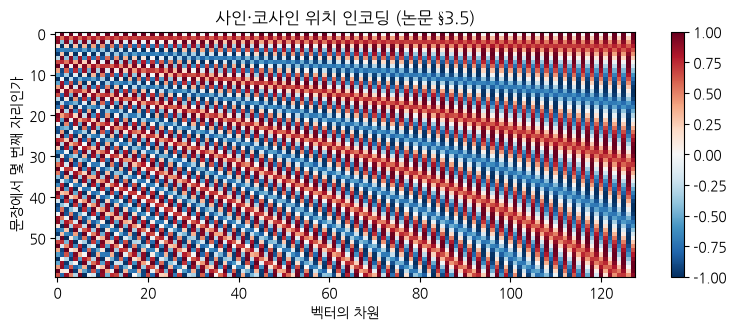

In [92]:
# 위치 인코딩 시각화
koplot.use_korean()
자리수, 차원수 = 60, 128        # 다 그리면 너무 커서 앞부분만 본다

fig, ax = plt.subplots(figsize=(8, 3.4))
im = ax.imshow(PE[:자리수, :차원수], aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xlabel("벡터의 차원")
ax.set_ylabel("문장에서 몇 번째 자리인가")
ax.set_title("사인·코사인 위치 인코딩 (논문 §3.5)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [93]:
학습된PE = BERT_model.embeddings.position_embeddings.weight.detach()

In [94]:
학습된PE.min(), 학습된PE.max()

(tensor(-0.5147), tensor(0.2457))

[koplot] 한글 폰트 적용: NanumGothic


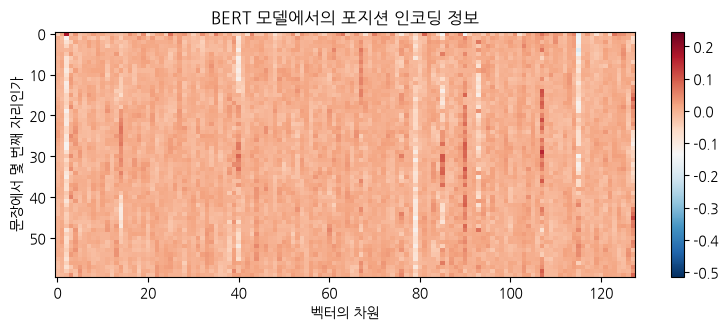

In [95]:
# 위치 인코딩 시각화
koplot.use_korean()

자리수, 차원수 = 60, 128        # 다 그리면 너무 커서 앞부분만 본다

fig, ax = plt.subplots(figsize=(8, 3.4))
im = ax.imshow(학습된PE[:자리수, :차원수], aspect="auto", cmap="RdBu_r", vmin=-0.5147, vmax=0.2457)
ax.set_xlabel("벡터의 차원")
ax.set_ylabel("문장에서 몇 번째 자리인가")
ax.set_title("BERT 모델에서의 포지션 인코딩 정보")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
# 벡터 공간의 지문을 통해 위치 정보에 대한 벡터를 가지게 된다.

In [96]:
사인유사도 = block.neighbor_similarity(PE)

In [97]:
사인유사도

{1: 0.9733597040176392,
 2: 0.9061431884765625,
 5: 0.7410470843315125,
 10: 0.6800279021263123,
 20: 0.616028904914856,
 50: 0.5120014548301697,
 100: 0.43688899278640747}

In [98]:
학습유사도 = block.neighbor_similarity(학습된PE)     #BERT 학습 임베딩도, 가까우면 유사도 높고 멀면 낮아짐

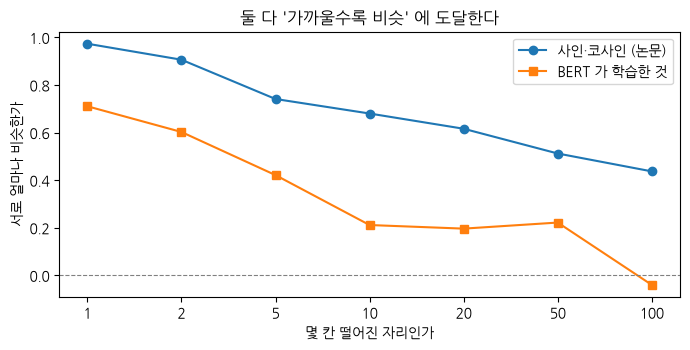

In [99]:
fig, ax = plt.subplots(figsize=(7, 3.6))
칸 = list(사인유사도.keys())
자리 = range(len(칸))                       # 눈금을 고르게 — 로그축을 쓰지 않는다
ax.plot(자리, [사인유사도[k] for k in 칸], marker="o", label="사인·코사인 (논문)")
ax.plot(자리, [학습유사도[k] for k in 칸], marker="s", label="BERT 가 학습한 것")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xticks(list(자리))
ax.set_xticklabels([str(k) for k in 칸])
ax.set_xlabel("몇 칸 떨어진 자리인가")
ax.set_ylabel("서로 얼마나 비슷한가")
ax.set_title("둘 다 '가까울수록 비슷' 에 도달한다")
ax.legend()
plt.tight_layout()
plt.show()

In [100]:
#블록 잔차 연결
깊이 = 12
x0 = torch.randn(1, 6, 8)   # 기준 텐서
x_그냥 = x0.clone()         #잔차 적용 없이 그냥
x_잔차 = x0.clone()         #잔차 적용
x_LN = x0.clone()           #잔차 + 정규화
층들 = [block.SelfAttention(8) for _ in range(깊이)]    # 12개의 어텐션층

In [101]:
# 잔차가 없이, 그냥 여러겹 쌓으면, 벡터 정보 신호의 크기가 사라져간다. 층을 통과할수록
크기_그냥 = []

for 층 in 층들:
    x_그냥, _ = 층(x_그냥)
    크기_그냥.append( x_그냥.norm().item() )
크기_그냥

[0.7635537981987,
 0.23639321327209473,
 0.05663831904530525,
 0.015899330377578735,
 0.004907326772809029,
 0.00297433789819479,
 0.000543519388884306,
 0.00023813788720872253,
 8.315526065416634e-05,
 4.948281275574118e-05,
 9.266035704058595e-06,
 2.642056188051356e-06]

In [102]:
# 잔차를 추가하면, 신호가 사라지는 대신, 신호가 남고 쌓여간다.
크기_잔차 = []

for 층 in 층들:             # 12개의 층 통과
    서브, _ = 층(x_잔차)
    x_잔차 = x_잔차 + 서브     # 값을 그냥 대입하는 게 아니라, 잔차를 더해주는 방식
    크기_잔차.append( x_잔차.norm().item() )
크기_잔차

[5.934764862060547,
 5.797338962554932,
 5.844422340393066,
 5.7995219230651855,
 5.837553977966309,
 5.784557342529297,
 5.897252559661865,
 6.005606651306152,
 6.049442768096924,
 6.160332679748535,
 6.1610026359558105,
 6.153788089752197]

In [103]:
정규화층들 = [ nn.LayerNorm(8) for _ in range(12) ]  # 12개의 정규화층

크기_LN = []

for 층, 정규화 in zip(층들, 정규화층들):             # 12개의 층 통과
    서브, _ = 층(x_LN)
    x_LN = 정규화(x_LN + 서브)     # 전차를 더해준 값을 정규화 층을 통과시켜줌.
    크기_LN.append( x_LN.norm().item() )
크기_LN

[6.928145408630371,
 6.928165435791016,
 6.928168773651123,
 6.928167343139648,
 6.928169250488281,
 6.928167343139648,
 6.928169250488281,
 6.928170204162598,
 6.928168773651123,
 6.928167819976807,
 6.928167819976807,
 6.928169250488281]

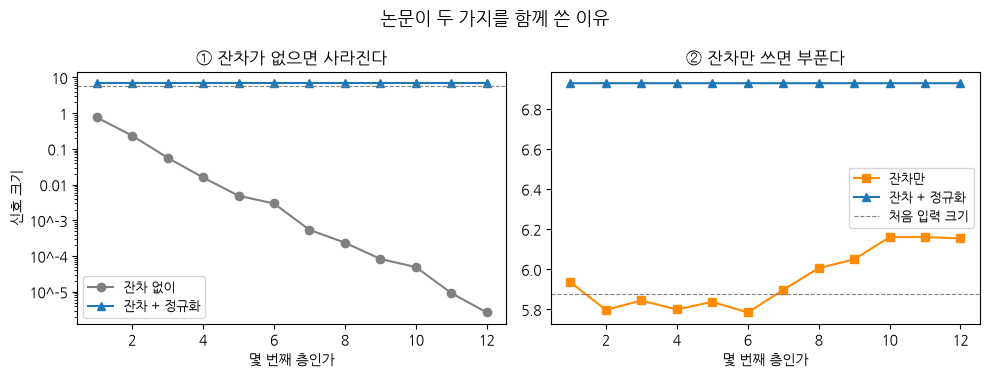

In [104]:
# 두 이야기를 한 그림에 겹치면 안 된다 — 로그축 하나에 셋을 얹으면
# "부푼다" 쪽이 직선처럼 눌려 안 보인다. 그래서 나눠 그린다.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
층번호 = list(range(1, 깊이 + 1))
처음 = x0.norm().item()

axes[0].plot(층번호, 크기_그냥, marker="o", color="gray", label="잔차 없이")
axes[0].plot(층번호, 크기_LN, marker="^", label="잔차 + 정규화")
axes[0].axhline(처음, color="gray", ls="--", lw=0.8)
axes[0].set_yscale("log")
koplot.ascii_log_axis(axes[0], "y")
axes[0].set_title("① 잔차가 없으면 사라진다")
axes[0].set_ylabel("신호 크기")

axes[1].plot(층번호, 크기_잔차, marker="s", color="darkorange", label="잔차만")
axes[1].plot(층번호, 크기_LN, marker="^", label="잔차 + 정규화")
axes[1].axhline(처음, color="gray", ls="--", lw=0.8, label="처음 입력 크기")
axes[1].set_title("② 잔차만 쓰면 부푼다")

for ax in axes:
    ax.set_xlabel("몇 번째 층인가")
    ax.legend(fontsize=9)
fig.suptitle("논문이 두 가지를 함께 쓴 이유", fontsize=13)
plt.tight_layout()
plt.show()

In [105]:
# FFN = 
# 입력 차원 = 차원을 증가 768 차원 * 4 = 3072 -> 768
# 넓게 펼쳐서 적절하게 골라 다시 원래 크기로 접는다.
d = 768
d_ff = 3072

내FFN = nn. Sequential(
    nn.Linear(d, d_ff),
    nn.GELU(),
    nn.Linear(d_ff, d),
)

In [106]:
sample = torch.randn(1, 4, d)
내FFN(sample[0, 1])

tensor([-0.3313,  0.3518, -0.0995, -0.1215,  0.2111, -0.0324,  0.0459, -0.1575,
         0.1179,  0.2080, -0.3968,  0.0761, -0.1865, -0.1931,  0.1307,  0.1569,
         0.1374,  0.0805,  0.1302,  0.0055, -0.0239,  0.0165,  0.0405,  0.1208,
         0.0157,  0.2916,  0.4365, -0.3208,  0.1399, -0.2188, -0.1224,  0.2641,
         0.2459,  0.0505, -0.2500, -0.0275,  0.4388,  0.1249, -0.3440, -0.3271,
        -0.1637, -0.0812, -0.0569, -0.1925,  0.1611,  0.0482,  0.1681,  0.1780,
         0.2372,  0.0476,  0.3104,  0.0675,  0.1199,  0.2073, -0.1907, -0.2249,
        -0.2557,  0.0346, -0.3073,  0.3202, -0.1051,  0.1054,  0.2312, -0.0934,
         0.0469, -0.1553,  0.0899, -0.0814, -0.1232,  0.1745, -0.2574, -0.0423,
        -0.0141,  0.2735, -0.0687, -0.1565, -0.1644, -0.1010, -0.3991,  0.1128,
        -0.1520, -0.1080,  0.3039,  0.0579, -0.0873,  0.1574, -0.2677,  0.3725,
         0.0712, -0.0026, -0.1688,  0.2318,  0.0385,  0.0347, -0.0130,  0.2648,
         0.0508, -0.0523, -0.1901, -0.03

In [139]:
d = 설정값.hidden_size
d_ff = 설정값.intermediate_size
h = 설정값.num_attention_heads

print(d, d_ff, h)
내블록 = block.내블록(d, d_ff, h=12)
내블록

768 3072 12


내블록(
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (ffn): Sequential(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=3072, out_features=768, bias=True)
  )
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
)

In [140]:
# 내 블록 파라미터 수
print(f"{block.n_params(내블록):,}")


7,087,872


In [141]:
# 버트 모델 블럭의 파라미터 수
layer0 = BERT_model.encoder.layer[0]
print(f"파라미터 수 : {block.n_params(layer0):,}")

파라미터 수 : 7,087,872


In [142]:
# 파이토치가 제공하는 트랜스포머 인코더 모델
토치블럭 = nn.TransformerEncoderLayer(d_model=d, nhead=h, dim_feedforward=d_ff, batch_first=True)
print(f"파라미터 수: {block.n_params(토치블럭) :,}")

파라미터 수: 7,087,872


In [143]:
# 파라미터 크기는 같지만, 내부 구조 이름들은 다름.
[ n for n, _ in 내블록.named_children() ] 
[ n for n, _ in layer0.named_children() ]
[ n for n, _ in 토치블럭.named_children() ]


['self_attn',
 'linear1',
 'dropout',
 'linear2',
 'norm1',
 'norm2',
 'dropout1',
 'dropout2']

In [144]:
print(f"파라미터 수 : {block.n_params(layer0) * 12:,}")
# GPT-3 모델 수는 175B, 175,000,000,000

파라미터 수 : 85,054,464


In [151]:
d = 설정값.hidden_size              # 768
d_ff = 설정값.intermediate_size     # 3072
attention_p = 4 * (d * d + d)      #Q, K, V, o 각각의 레이어 가중치(제곱) + 편향
ffn_p = (d * d_ff + d_ff) + (d_ff * d + d_ff)   # 레이어 2개 통과
layer_norm_p = 2 * (2 * (d))    # LayerNomarl 통과

attention_p + ffn_p + layer_norm_p

7090176

In [ ]:
# 마스킹
mask = torch.triu(torch.ones(5, 5), diagonal=1)
mask
# 셀프 어텐션 -> scaled-dot-product 과정에 해당 mask를 씌우고 -inf 값을 대입하면 masked attention (디코더에 사용)

tensor([[0., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1.],
        [0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0.]])